1 = attack 
0 = normal

In [16]:
# Data structures
import pandas as pd
import numpy as np

#Visulization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning 
from sklearn.linear_model import LinearRegression, LogisticRegression


In [ ]:
# import dataset
df = pd.read_csv("/Users/dawsonconlon/Data/Cybersecurity Intrusion Data.csv")

#print(df.head(20))
print(df.describe())

       network_packet_size  login_attempts  session_duration  \
count          9537.000000     9537.000000       9537.000000   
mean            500.430639        4.032086        792.745312   
std             198.379364        1.963012        786.560144   
min              64.000000        1.000000          0.500000   
25%             365.000000        3.000000        231.953006   
50%             499.000000        4.000000        556.277457   
75%             635.000000        5.000000       1105.380602   
max            1285.000000       13.000000       7190.392213   

       ip_reputation_score  failed_logins  unusual_time_access  \
count          9537.000000    9537.000000          9537.000000   
mean              0.331338       1.517773             0.149942   
std               0.177175       1.033988             0.357034   
min               0.002497       0.000000             0.000000   
25%               0.191946       1.000000             0.000000   
50%               0.314778 

In [11]:
print(df["attack_detected"].value_counts(normalize=True) * 100) 

attack_detected
0    55.289923
1    44.710077
Name: proportion, dtype: float64


Normal behaviour occures more often than attacks in this dataset but they are almost 50/50 which gives us lots of information to crack down on what variables are highly corrilated with attacks.

I am going to explore the attack_detected column, first I will split the data frame into 2 based on attack detected and not.

In [ ]:
# split the data

attack_df = df[df["attack_detected"] == 1]
nomal_df = df[df["attack_detected"] == 0]

In [40]:
attack_df.mean(numeric_only=True)

network_packet_size    498.931051
login_attempts           4.637430
session_duration       829.131980
ip_reputation_score      0.373015
failed_logins            1.935976
unusual_time_access      0.153377
attack_detected          1.000000
dtype: float64

Packet size 

network_packet_size (Packet Size in Bytes)

Represents the size of network packets, ranging between 64 to 1500 bytes.
Packets on the lower end (~64 bytes) may indicate control messages, while larger packets (~1500 bytes) often carry bulk data.
Attackers may use abnormally small or large packets for reconnaissance or exploitation attempts.

                  count        mean         std   min    25%    50%     75%  \
attack_detected                                                               
0                5273.0  501.643277  197.635263  64.0  368.0  498.0  634.00   
1                4264.0  498.931051  199.308695  64.0  361.0  500.0  635.25   

                    max  
attack_detected          
0                1285.0  
1                1270.0  


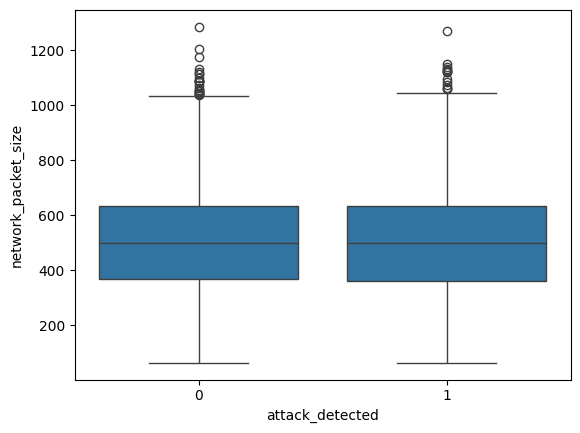

In [18]:
# Do attacks use differnet packet sizes
a_packet = df.groupby("attack_detected")["network_packet_size"].describe()
print(a_packet)

# Visulize 
sns.boxplot(x = "attack_detected", y = "network_packet_size",
              data = df)
plt.show()

Network packet size seems to not be a good differentiator between attacks and normal behaviour. 
This is probably because attacks can use small or large packet sizes the same way normal cyber behviour can as well, thats why we see very little difference in the mean,
standard deveation etc. 

The protocol used in the session: TCP, UDP, or ICMP.
TCP (Transmission Control Protocol): Reliable, connection-oriented (common for HTTP, HTTPS, SSH).
UDP (User Datagram Protocol): Faster but less reliable (used for VoIP, streaming).
ICMP (Internet Control Message Protocol): Used for network diagnostics (ping); often abused in Denial-of-Service (DoS) attacks.

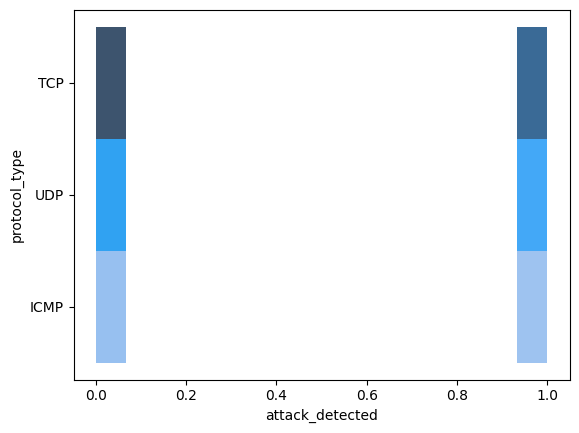

attack_detected,0,1
protocol_type,,
ICMP,0.587771,0.412229
TCP,0.552687,0.447313
UDP,0.546135,0.453865


In [27]:
# protocal type
sns.histplot(x = "attack_detected", y = "protocol_type",
             data = df)
plt.show()

pd.crosstab(df['protocol_type'], df['attack_detected'], normalize='index')

All protocals are attacked pretty much equally.

encryption_used (Encryption Protocol)

Values: AES, DES, None.
AES (Advanced Encryption Standard): Strong encryption, commonly used.
DES (Data Encryption Standard): Older encryption, weaker security.

In [24]:
# encription 
pd.crosstab(df["encryption_used"], df["attack_detected"])

attack_detected,0,1
encryption_used,,
AES,2651,2055
DES,1566,1299


Attacks seem to use advanced encryption more often than older encrytion methods which makes sense in the ever advancing world of hacking.  

User behaviour analysis 

login_attempts (Number of Logins)

High values might indicate brute-force attacks (repeated login attempts).
Typical users have 1–3 login attempts, while an attack may have hundreds or thousands.

In [28]:
# log-in attempts
df.groupby("attack_detected")["login_attempts"].describe()

,count,mean,std,min,25%,50%,75%,max
attack_detected,,,,,,,,
0,5273.0,3.542575,1.507108,1.0,2.0,4.0,5.0,6.0
1,4264.0,4.637430,2.268897,1.0,3.0,4.0,6.0,13.0


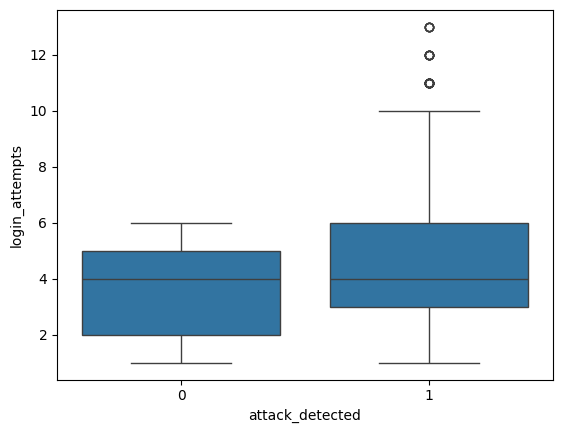

In [39]:
sns.boxplot(x = "attack_detected", y = "login_attempts",
              data = df)
plt.show()

Here is our first real insight; attackers are having more log in attempts than non attackers.
This makes sense as users usally know there passwords no issue, but a hacker will usally have to attempt to log-in more frequently. 

Not a single non hacker attempted to login more than 6 times where as hackers are shown to attempt to log in > 12 times.

On average hacker wil be attempting to logging in around 5 times. 

failed_logins (Failed Login Attempts)

High failed login counts indicate credential stuffing or dictionary attacks.
Many failed attempts followed by a successful login could suggest an account was compromised

In [41]:
# failed logins 
df.groupby("attack_detected")["failed_logins"].describe()

,count,mean,std,min,25%,50%,75%,max
attack_detected,,,,,,,,
0,5273.0,1.179594,0.736657,0.0,1.0,1.0,2.0,2.0
1,4264.0,1.935976,1.184932,0.0,1.0,2.0,3.0,5.0


Failed logisn go hand in hand with hackers having more login attempts, hackers will have more failed logins compared to normal users.

ip_reputation_score (Trustworthiness of IP Address)

In [42]:
df.groupby('attack_detected')['ip_reputation_score'].describe()

,count,mean,std,min,25%,50%,75%,max
attack_detected,,,,,,,,
0,5273.0,0.297636,0.147434,0.007030,0.177466,0.293780,0.412074,0.599703
1,4264.0,0.373015,0.200488,0.002497,0.211048,0.347314,0.525693,0.924299


Hackers have higher Ip_reputation scores 

In [43]:
df.groupby('attack_detected')['session_duration'].describe()

,count,mean,std,min,25%,50%,75%,max
attack_detected,,,,,,,,
0,5273.0,763.321311,728.250219,0.5,232.042818,554.069552,1066.236472,7190.392213
1,4264.0,829.131980,851.857703,0.5,231.664142,559.358924,1166.808449,7141.336086


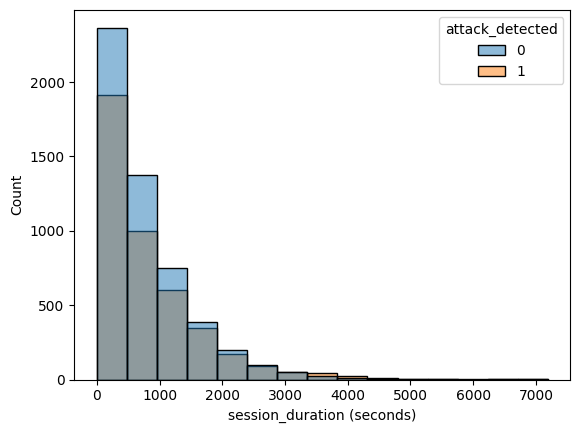

In [50]:
sns.histplot(data=df, x='session_duration', hue='attack_detected', bins=15)
plt.xlabel("session_duration (seconds)")
plt.show()

Hackers are having longer sessions than normal users becuase of login attempts and just overall the nature of what a hacker is doing is going to take more time.
Almost all attacks have a session thats > than 50 minutes.

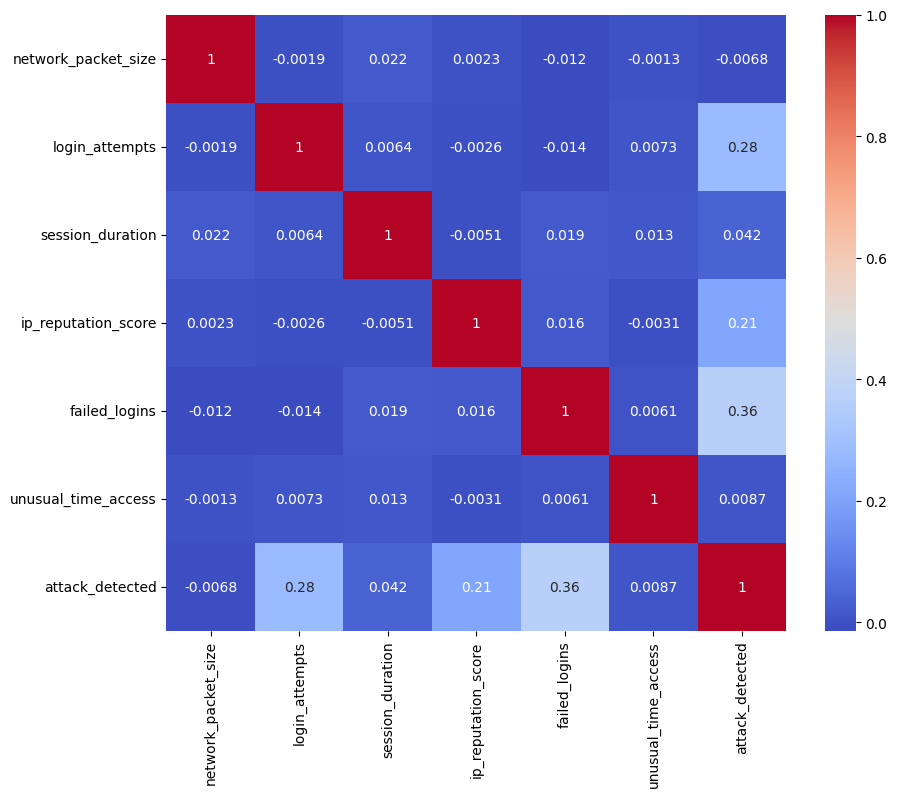

In [51]:
# corrilation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

Based on out previouse isnights and the heat corilation map we can see login attempts, failed logins and ip_reputation score are the most signifcant features in corilation with attacks being detected.

I am going to further look into the top 3 features. 

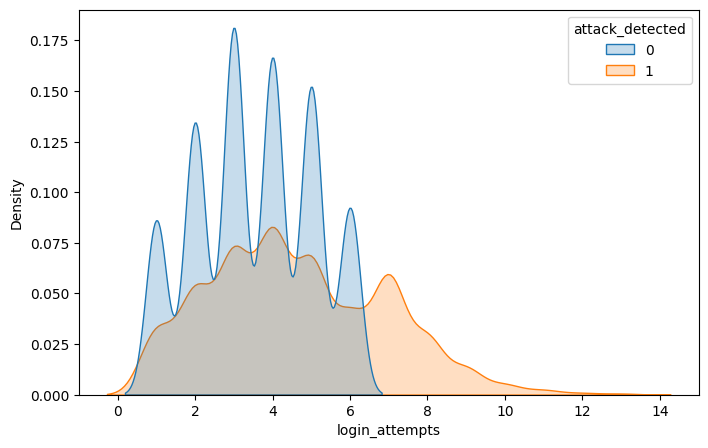

In [56]:
plt.figure(figsize=(8,5))
sns.kdeplot(x = "login_attempts", hue = "attack_detected", fill = True, data = df)
plt.show()

So the most attacks recorded had around 4 login attempts. But the graph shows that only attacks where detected after 6 logins, meaning anything after six logins should be a major flag.

In [60]:
# I want to find out attack rate by login attempt 
df["login_bucket"] = pd.cut(
    df["login_attempts"],
    bins = [0,2,5,10,20,50]
)

attack_rate = df.groupby("login_bucket")["attack_detected"].mean()
attack_rate

/var/folders/hv/tj8zjgyd3qncstnpt_ttykgr0000gn/T/ipykernel_12092/2412398287.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attack_rate = df.groupby("login_bucket")["attack_detected"].mean()


login_bucket
(0, 2]      0.358584
(2, 5]      0.388229
(5, 10]     0.695939
(10, 20]    1.000000
(20, 50]         NaN
Name: attack_detected, dtype: float64

The probability of attack increases sharply once login attempts exceed five.
All sessions with more than ten login attempts were labeled as malicious, indicating a clear brute-force signature threshold in the dataset.


One question I want to answer is after many failed logins followed by a succesfull login, is this brute force

In [61]:
df.groupby("attack_detected")["failed_logins"].describe()

,count,mean,std,min,25%,50%,75%,max
attack_detected,,,,,,,,
0,5273.0,1.179594,0.736657,0.0,1.0,1.0,2.0,2.0
1,4264.0,1.935976,1.184932,0.0,1.0,2.0,3.0,5.0


In [63]:
df['failed_bucket'] = pd.cut(
    df['failed_logins'],
    bins=[0,1,3,5,10,50]
)

df.groupby('failed_bucket')['attack_detected'].mean()

/var/folders/hv/tj8zjgyd3qncstnpt_ttykgr0000gn/T/ipykernel_12092/3330810702.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('failed_bucket')['attack_detected'].mean()


failed_bucket
(0, 1]      0.337275
(1, 3]      0.532330
(3, 5]      1.000000
(5, 10]          NaN
(10, 50]         NaN
Name: attack_detected, dtype: float64

After 3 failed login attempts there is pretty much a certinity that there is an attack goig on. 

In [64]:
df['ip_bucket'] = pd.cut(
    df['ip_reputation_score'],
    bins=[0,0.2,0.4,0.6,0.8,1.0]
)

df.groupby('ip_bucket')['attack_detected'].mean()

/var/folders/hv/tj8zjgyd3qncstnpt_ttykgr0000gn/T/ipykernel_12092/2966405119.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('ip_bucket')['attack_detected'].mean()


ip_bucket
(0.0, 0.2]    0.379717
(0.2, 0.4]    0.408948
(0.4, 0.6]    0.396131
(0.6, 0.8]    1.000000
(0.8, 1.0]    1.000000
Name: attack_detected, dtype: float64

Users with an IP score greater than 0.6 are always hackers in this data set

Now that I have a general sense of what a hacker is, I am going to create high risk catagorys withi the df 

In [78]:
df['high_login'] = df['login_attempts'] > 5
df['high_ip'] = df['ip_reputation_score'] > 0.5
df['high_failed'] = df['failed_logins'] > 3

In [79]:
pd.crosstab(
    [df['high_login'], df['high_ip']],
    df['attack_detected'],
    normalize='index'
)

attack_detected            0         1
high_login high_ip                    
False      False    0.680809  0.319191
           True     0.368022  0.631978
True       False    0.322830  0.677170
           True     0.173375  0.826625

When a user does not have > 5 login attempts and there ip score is < 0.5, there is a 70% chance they are not a hacker

Any user with a ip score > 0.5 has a 63% chance of being a hacker 

Users with high ip scores that fail to login > 5 times, have a 83% chance of being a hacker







Lets catagorize the average hacker

In [80]:
df[df['attack_detected']==1].mean(numeric_only=True)

network_packet_size    498.931051
login_attempts           4.637430
session_duration       829.131980
ip_reputation_score      0.373015
failed_logins            1.935976
unusual_time_access      0.153377
attack_detected          1.000000
high_login               0.329737
high_ip                  0.277674
high_failed              0.075750
dtype: float64

In [81]:
# normal user
df[df['attack_detected']==0].mean(numeric_only=True)

network_packet_size    501.643277
login_attempts           3.542575
session_duration       763.321311
ip_reputation_score      0.297636
failed_logins            1.179594
unusual_time_access      0.147165
attack_detected          0.000000
high_login               0.113598
high_ip                  0.111891
high_failed              0.000000
dtype: float64

Hackers and normal users on average have around the same network packet size 

Hackers will attempt to loging around 5 times

Hackers will have sessions on average of 15 minutes 

Hackers on average have an IP score of 0.4

Hackers fail to login on a ratio of 2:1 compared to a normal user

